In [1]:
import pandas as pd
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

url = URL.create(
    drivername="mysql+pymysql",
    username="root",
    password="***",
    host="localhost",
    port=3306,
    database="encommerce_analysis"
)
engine = create_engine(url)

user_sql = """
SELECT
    customer_unique_id,
    SUM(price) AS total_spend,
    COUNT(DISTINCT orders.order_id) AS order_count,
    SUM(price)/COUNT(DISTINCT orders.order_id) AS avg_order_value,
    MIN(order_purchase_timestamp) AS first_purchase,
    MAX(order_purchase_timestamp) AS last_purchase
FROM customer
JOIN orders
    ON customer.customer_id = orders.customer_id
JOIN order_items
    ON orders.order_id = order_items.order_id
WHERE order_status = 'delivered'
    AND order_purchase_timestamp >= '2017-01-01'
    AND order_purchase_timestamp < '2018-09-01'
GROUP BY customer_unique_id;
"""

user_behavior = pd.read_sql(user_sql, engine)

In [7]:
# 去掉id列的双引号，方便后续分析工作
user_behavior["customer_unique_id"] = (user_behavior["customer_unique_id"]
    .str.strip().str.strip('"'))
# 查看数据属性
print(user_behavior.shape)
print(user_behavior.info())
print(user_behavior.isnull().sum())
print(user_behavior.head())
# 查看这份数据的一些基本情况
print(user_behavior[["total_spend", "order_count", "avg_order_value"]].describe())

(93104, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93104 entries, 0 to 93103
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_unique_id  93104 non-null  object        
 1   total_spend         93104 non-null  float64       
 2   order_count         93104 non-null  int64         
 3   avg_order_value     93104 non-null  float64       
 4   first_purchase      93104 non-null  datetime64[ns]
 5   last_purchase       93104 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float64(2), int64(1), object(1)
memory usage: 4.3+ MB
None
customer_unique_id    0
total_spend           0
order_count           0
avg_order_value       0
first_purchase        0
last_purchase         0
dtype: int64
                 customer_unique_id  total_spend  order_count  \
0  0000366f3b9a7992bf8c76cfdf3221e2       129.90            1   
1  0000b849f77a49e4a4ce2b2a4ca5be3f        18.90            

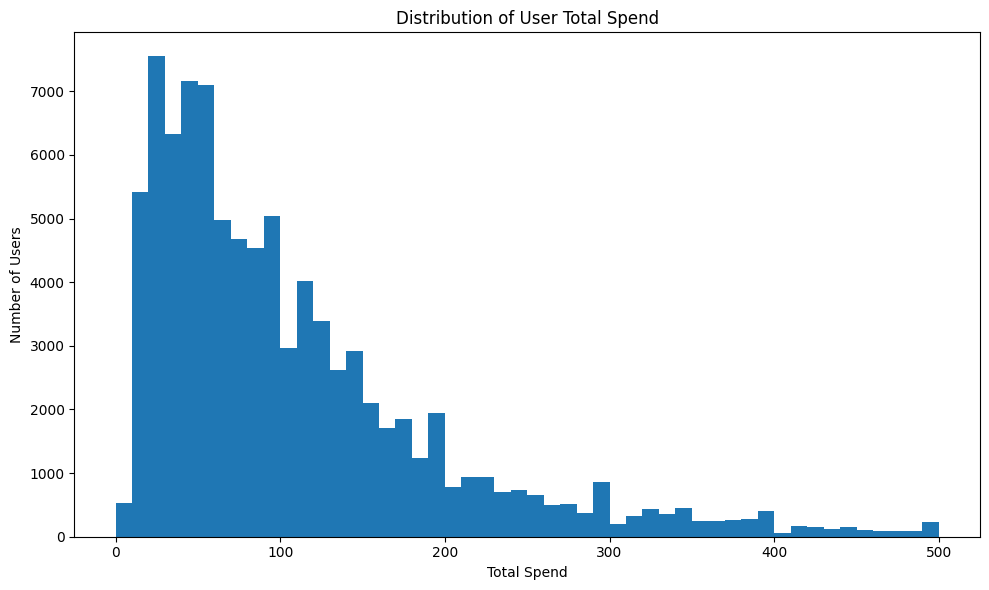

人数最多的消费区间： 20.0 - 30.0
该区间用户数： 7550


In [12]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(10, 6))
# 将消费金额分成50个区间，只取0-500金额数据进行分析
plt.hist(
    user_behavior["total_spend"],
    bins=50,
    range=(0, 500)
)
plt.xlabel("Total Spend")
plt.ylabel("Number of Users")
plt.title("Distribution of User Total Spend")
plt.tight_layout()
plt.show()

# 统计人数最多的区间以及具体用户数
counts, edges = np.histogram(user_behavior["total_spend"],bins=50,range=(0, 500))
max_index = counts.argmax()
print("人数最多的消费区间：", edges[max_index], "-", edges[max_index + 1])
print("该区间用户数：", counts[max_index])

In [15]:
# 开始对消费金额较高的高消费用户进行一些分析
user_spend_rank = user_behavior.sort_values(by="total_spend",ascending=False).copy()
print(user_spend_rank.head(10))
# 计算用户总数的10%
import math
top10_n = math.ceil(len(user_spend_rank) * 0.1)
print(top10_n)
top10_users = user_spend_rank.head(top10_n)

top10_sales = top10_users["total_spend"].sum()
total_sales = user_behavior["total_spend"].sum()
top10_share = top10_sales / total_sales * 100
print("前10%用户销售额：", top10_sales)
print("总销售额：", total_sales)
print("前10%用户销售贡献率：", top10_share)

                     customer_unique_id  total_spend  order_count  \
3716   0a0a92112bd4c708ca5fde585afaa872      13440.0            1   
79420  da122df9eeddfedc1dc1f5349a1a690c       7388.0            2   
43051  763c8b1c9c68a0229c42c9fc6f662b93       7160.0            1   
80246  dc4802a71eae9be1dd28f5d788ceb526       6735.0            1   
25360  459bef486812aa25204be022145caa62       6729.0            1   
92831  ff4159b92c40ebe40454e3e6a7c35ed6       6499.0            1   
23341  4007669dec559734d6f53e029e360987       5934.6            1   
86913  eebb5dda148d3893cdaf5b5ca3040ccb       4690.0            1   
26562  48e1ac109decbb87765a3eade6854098       4590.0            1   
59006  a229eba70ec1c2abef51f04987deb7a5       4400.0            1   

       avg_order_value      first_purchase       last_purchase  
3716           13440.0 2017-09-29 15:24:52 2017-09-29 15:24:52  
79420           3694.0 2017-04-01 15:58:40 2017-04-01 15:58:41  
43051           7160.0 2018-07-15 14:49:44 20

In [20]:
print(top10_users["order_count"].value_counts().sort_index())
print(user_behavior["order_count"].value_counts().sort_index())
# 前10%用户及复购消费情况
top10_once = top10_users[top10_users["order_count"] == 1]
top10_repeat = top10_users[top10_users["order_count"] >= 2]
print("Top10%单次购买用户人均消费：",top10_once["total_spend"].mean())
print("Top10%重复购买用户人均消费：",top10_repeat["total_spend"].mean())
print("Top10%单次购买用户消费总额：",top10_once["total_spend"].sum())
print("Top10%重复购买用户消费总额：",top10_repeat["total_spend"].sum())
# 整体用户及复购消费情况
once_users = user_behavior[user_behavior["order_count"] == 1]
repeat_users = user_behavior[user_behavior["order_count"] >= 2]
print("单次购买用户人均消费：",once_users["total_spend"].mean())
print("重复购买用户人均消费：",repeat_users["total_spend"].mean())
print("单次购买用户消费总额：",once_users["total_spend"].sum())
print("重复购买用户消费总额：",repeat_users["total_spend"].sum())

order_count
1     8511
2      675
3       84
4       24
5        8
6        4
7        3
9        1
15       1
Name: count, dtype: int64
order_count
1     90315
2      2562
3       180
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64
Top10%单次购买用户人均消费： 585.4018199976501
Top10%重复购买用户人均消费： 543.9223
Top10%单次购买用户消费总额： 4982354.890000001
Top10%重复购买用户消费总额： 435137.83999999997
单次购买用户人均消费： 137.9136587499308
重复购买用户人均消费： 260.0771029042668
单次购买用户消费总额： 12455672.09
重复购买用户消费总额： 725355.04


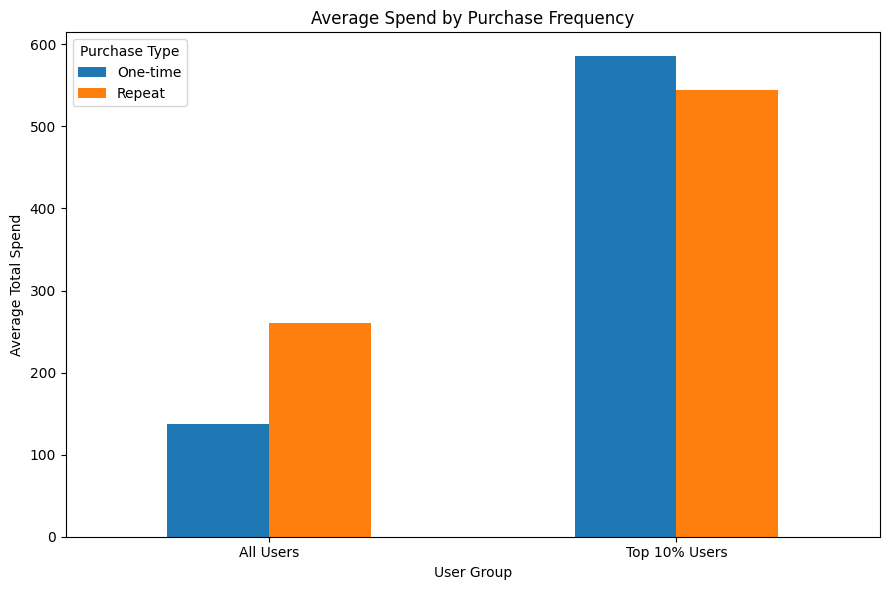

In [21]:
# 复购分析数据可视化
# 建立可视化数据框架
compare_df = pd.DataFrame({"group": ["All Users", "Top 10% Users"],
    "One-time": [137.91, 585.40],"Repeat": [260.08, 543.92]})
# 画对比柱状图
compare_df.plot(
    x="group",y=["One-time", "Repeat"],
    kind="bar",figsize=(9, 6),rot=0)
plt.ylabel("Average Total Spend")
plt.xlabel("User Group")
plt.title("Average Spend by Purchase Frequency")
plt.legend(title="Purchase Type")
plt.tight_layout()
plt.show()

In [22]:
print("单次购买用户平均客单价：",once_users["avg_order_value"].mean())
print("复购用户平均客单价：",repeat_users["avg_order_value"].mean())

单次购买用户平均客单价： 137.9136587499308
复购用户平均客单价： 122.94641395876657
